### normalizing the Data

Furthermore, while some machine learning algorithms such as tree-based methods (e.g.
Random Forest) can deal with native value distributions such as full integers and some even
categorical inputs, other methods need further processing. Linear regression methods,
SVMs, and especially any type of neural network need the data to be scaled to a range
around 0 to be numerically stable during their optimization procedure. Maybe your insights
from Q1.2 can help you choose appropriate scaling methods? Choose, apply, and reason
about your scaling method. (1 pt)
Careful: scaling methods and the like should always only be fitted on the training set!

In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split as tts
def ret_path(imputeds:str, which_dataset:str):
    return f"parquet_files/processedDataProxy-{which_dataset}-{imputeds}.parquet"

data_a_imputed:pd.DataFrame = pd.read_parquet(ret_path("imputed", "a"))
data_c_imputed:pd.DataFrame = pd.read_parquet(ret_path("imputed", "c"))


## get training and test data
take the mean of all vars over 28 hours. so take the mean of a column of all rows whos other columns has the same patient id. 
Split data into X and y and then into X train and y train and X test and y test

In [59]:
data_per_patient_mean = data_a_imputed.groupby("PatientID").mean()
X = data_per_patient_mean.drop(columns =['RecordID_y', 'In-hospital_death', 'RecordID_x', 'Time'])
y = data_per_patient_mean["In-hospital_death"]

data_per_patient_mean_c = data_c_imputed.groupby("PatientID").mean()
X_c = data_per_patient_mean_c.drop(columns=['RecordID_y', 'In-hospital_death', 'RecordID_x', 'Time'])
print(X_c.columns.symmetric_difference(X.columns))
y_c = data_per_patient_mean_c["In-hospital_death"]

Index([], dtype='str')


In [53]:
Xtrain,  Xtest,ytrain, ytest = tts(X, y, test_size=0.33)


In [43]:
data

,Time,Age,BUN,Creatinine,GCS,Gender,Glucose,HCO3,HCT,HR,...,pH,DiasABP,MAP,SaO2,SysABP,Lactate,Cholesterol,TroponinI,RecordID_y,In-hospital_death
0,0,35.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,132592,0
1,1,35.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,132592,0
2,2,35.0,-1.0,-1.0,15.0,0.0,-1.0,-1.0,-1.0,112.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,132592,0
3,3,35.0,68.0,2.3,15.0,0.0,603.0,11.0,25.5,113.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,132592,0
4,4,35.0,68.0,2.3,15.0,0.0,603.0,11.0,25.5,112.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,132592,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195995,44,56.0,9.0,0.4,15.0,1.0,107.0,29.0,34.4,95.0,...,7.4,81.0,103.0,91.0,150.0,1.1,-1.0,-1.0,141565,0
195996,45,56.0,9.0,0.4,15.0,1.0,107.0,29.0,34.4,94.0,...,7.4,84.0,105.0,91.0,151.0,1.1,-1.0,-1.0,141565,0
195997,46,56.0,9.0,0.4,15.0,1.0,107.0,29.0,34.4,100.0,...,7.4,95.0,116.0,91.0,167.0,1.1,-1.0,-1.0,141565,0
195998,47,56.0,9.0,0.4,15.0,1.0,107.0,29.0,34.4,99.0,...,7.4,70.0,88.0,91.0,131.0,1.1,-1.0,-1.0,141565,0


## Normalize the train and test data based on the training datas mean and var

In [54]:
from sklearn.preprocessing import RobustScaler
regularizer = RobustScaler().set_output(transform="pandas").fit(Xtrain)# it takes median instead of mean and as such is a bit more robust to ouliers. our data sometimes has a rightward tail. 


In [60]:
X_train_reg = regularizer.transform(Xtrain)
X_test_reg = regularizer.transform(Xtest)
#transform the test
X_c = X_c[X_train_reg.columns]
X_c_transformed = regularizer.transform(X_c)


## classic Methods


In [61]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_reg, ytrain)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [62]:
from sklearn.metrics import classification_report
predictions = model.predict(X_test_reg)
print(classification_report(predictions, ytest))
predictions_c = model.predict(X_c_transformed)
print(classification_report(predictions_c, y_c))




              precision    recall  f1-score   support

         0.0       0.97      0.87      0.92      1255
         1.0       0.17      0.51      0.26        65

    accuracy                           0.86      1320
   macro avg       0.57      0.69      0.59      1320
weighted avg       0.93      0.86      0.89      1320

              precision    recall  f1-score   support

         0.0       0.97      0.88      0.92      3780
         1.0       0.22      0.57      0.31       220

    accuracy                           0.86      4000
   macro avg       0.59      0.73      0.62      4000
weighted avg       0.93      0.86      0.89      4000



In [63]:
from sklearn.metrics import roc_auc_score, average_precision_score
y_probs = model.predict_proba(X_c_transformed)[:, 1]
auroc = roc_auc_score(y_c, y_probs)
print(f"AUROC: {auroc:.4f}")

# Calculate AUPRC (Area Under the Precision-Recall Curve)
# In scikit-learn, this is called average_precision_score
auprc = average_precision_score(y_c, y_probs)
print(f"AUPRC: {auprc:.4f}")

AUROC: 0.8230
AUPRC: 0.4468


# This was model 1, next is model 2

## Todo learn the metrics and how to use them and also learn about random forests


In [66]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train_reg, ytrain)
y_probs = model.predict_proba(X_c_transformed)[:, 1]
auroc = roc_auc_score(y_c, y_probs)
print(f"Auroc: {auroc}")
auprc = average_precision_score(y_c, y_probs)
print(f"AUPRC: {auprc:.4f}")


Auroc: 0.8105317165346447
AUPRC: 0.4338


# TODO
Feature design and engineering is important for classic ML methods, especially when
applied to time-series, since many classical methods do not explicitly consider a time
dimension. Repeat (1) with additional features of your choice, try to improve the
predictive performance of your method, and report again test set performance (3pts).
See e.g. https://tsfresh.readthedocs.io/en/latest/ for signal processing-based
features, which can help static models such as linear regression gain temporal
insights through smart feature extraction. Report test set C performance (AuROC
and AuPRC) (3pts).

## Next up: more features (min, max)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


data_a_imputed_max:pd.DataFrame=  data_a_imputed.groupby("PatientID").max().add_suffix("_max", axis=1)
data_a_imputed_min:pd.DataFrame=  data_a_imputed.groupby("PatientID").min().add_suffix("_min", axis=1)
data_a_imputed_mean:pd.DataFrame=  data_a_imputed.groupby("PatientID").mean().add_suffix("_mean", axis=1)
a_mmm = pd.concat([data_a_imputed_max, data_a_imputed_mean, data_a_imputed_min], axis = 1)
sol_cols:list[str] = [a for a in a_mmm.columns if "death" in a]
a_mmm_X =a_mmm.drop(columns=sol_cols)
a_mmm_y = a_mmm["In-hospital_death_max"]

data_c_imputed_max = data_c_imputed.groupby("PatientID").max().add_suffix("_max", axis = 1)
data_c_imputed_min = data_c_imputed.groupby("PatientID").min().add_suffix("_min", axis= 1)
data_c_imputed_mean = data_c_imputed.groupby("PatientID").mean().add_suffix("_mean", axis=1)

c_mmm = pd.concat([data_c_imputed_max, data_c_imputed_mean, data_c_imputed_min], axis=1)

sol_cols:list[str] = [a for a in c_mmm.columns if "death" in a]
c_mmm_X = c_mmm.drop(columns=sol_cols)
c_mmm_X = c_mmm_X[a_mmm_X.columns]
c_mmm_y = c_mmm["In-hospital_death_max"]

##need to scale data

#we might also have to adapt the data distributions to the method...
#lets first check the model without


logi_model = make_pipeline(SimpleImputer(missing_values=-1, strategy='median'), StandardScaler(),LogisticRegression())
logi_model.fit(X = a_mmm_X, y= a_mmm_y)
print(set(a_mmm_X.columns)^set(c_mmm_X.columns))

probs  =logi_model.predict_proba(c_mmm_X)[:,1]
print(roc_auc_score(c_mmm_y,probs))
print(average_precision_score(c_mmm_y, probs))



set()
0.8242229480296831
0.4379845578667725


/Users/samuelgair/Desktop/local githum ml4h/ML4HC-Project1/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['SaO2_min' 'TroponinI_min']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/samuelgair/Desktop/local githum ml4h/ML4HC-Project1/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['SaO2_min' 'TroponinI_min']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


# Following the instructions for additional features from tsfresh

In [33]:
import sys
print(sys.executable)

/Users/samuelgair/Desktop/local githum ml4h/ML4HC-Project1/.venv/bin/python


array([<Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='Time'>,
       <Axes: xlabel='Time'>, <Axes: xlabel='T

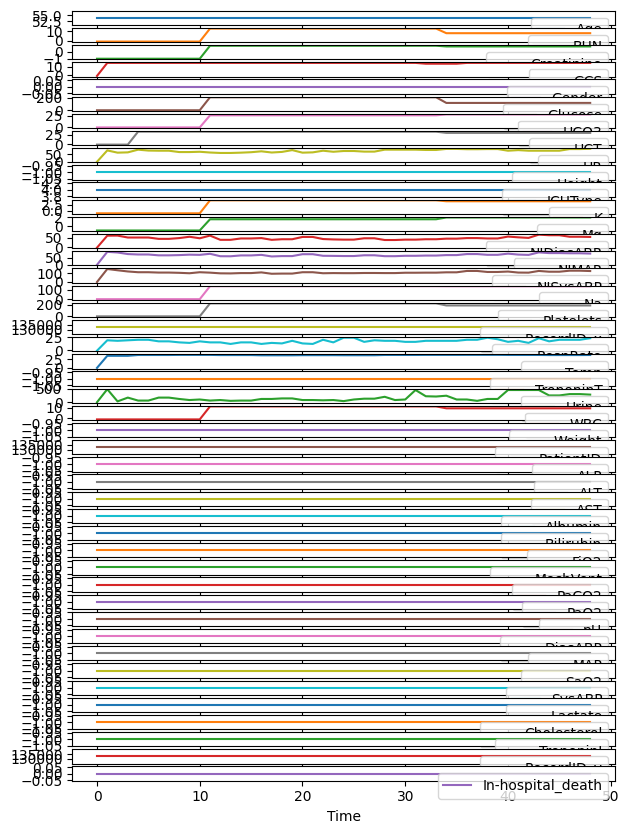

In [45]:
data_a_imputed[data_a_imputed["PatientID"] ==132539].set_index("Time").plot(sharex=True, subplots=True, figsize=(7, 10))

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from tsfresh import extract_features 
from tsfresh.feature_extraction import EfficientFCParameters

# 1. Load the data
path = ret_path("not-imputed", "a")
raw_df = pd.read_parquet(path=path)

# 2. Kill the Infs
raw_df = raw_df.replace([np.inf, -np.inf], np.nan)

# 3. Safely Groupby, forward-fill, and fill the rest with -1
data_minus_oned = raw_df.set_index("PatientID").groupby("PatientID").ffill().fillna(-1).reset_index()

# 4. Impute
imputer = SimpleImputer(missing_values=-1, strategy='median')
imputer.set_output(transform="pandas") 
data_imputed = imputer.fit_transform(data_minus_oned)

# 5. THE FIX: Round the numeric columns to 4 decimals to kill micro-variances!
numeric_cols = data_imputed.select_dtypes(include=[np.number]).columns
data_imputed[numeric_cols] = data_imputed[numeric_cols].round(4)

# 6. Extract! 
extracted_features = extract_features(data_imputed, column_id="PatientID", column_sort="Time",default_fc_parameters=EfficientFCParameters(), n_jobs = 0)

Feature Extraction:   2%|▏         | 2944/176000 [01:46<1:44:13, 27.67it/s]
Process SpawnPoolWorker-13:
Process SpawnPoolWorker-16:
Process SpawnPoolWorker-15:
Process SpawnPoolWorker-14:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/samuelgair/miniforge3/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/samuelgair/miniforge3/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/samuelgair/miniforge3/lib/python3.12/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/Users/samuelgair/miniforge3/lib/python3.12/multiprocessing/queues.py", line 386, in get
    with self._rlock:
         ^^^^^^^^^^^
  File "/Users/samuelgair/miniforge3/lib/python3.12/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__en

KeyboardInterrupt: 

Process SpawnPoolWorker-9:
Traceback (most recent call last):
  File "/Users/samuelgair/miniforge3/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/samuelgair/miniforge3/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/samuelgair/miniforge3/lib/python3.12/multiprocessing/pool.py", line 131, in worker
    put((job, i, result))
  File "/Users/samuelgair/miniforge3/lib/python3.12/multiprocessing/queues.py", line 393, in put
    obj = _ForkingPickler.dumps(obj)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/samuelgair/miniforge3/lib/python3.12/multiprocessing/reduction.py", line 51, in dumps
    cls(buf, protocol).dump(obj)
KeyboardInterrupt
Process SpawnPoolWorker-10:
Process SpawnPoolWorker-12:
Process SpawnPoolWorker-11:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/samuelgair/miniforge3/lib/python3.12/multiprocessing/proce